In [1]:
# %matplotlib notebook
import pandas as pd
import numpy as np

import sys
sys.path.append('Utils/')


import scipy
import scanpy
import matplotlib.pyplot as plt

from cycleGRN import bin_traj, train_ours,traj_ours,build_laplacian,find_Lie_derivative
from cycleGRN import time_lagged_correlation, time_lagged_Granger, time_lagged_Granger_CV_fast,pick_k_threshold
import cellrank as cr
from spatial_velocity import orient_flow_by_cell_cycle_phase


%load_ext autoreload
%autoreload 2

# First, process scEU-seq data (GEO: GSE128365)

In [2]:
import pandas as pd
import numpy as np
import anndata as ad
import scipy.sparse as sp

def read_counts_csv(path):
    # If files are .csv.gz, this will still work; otherwise harmless.
    return pd.read_csv(path, index_col=0, compression="infer")

def clean_ids(x):
    # normalize to string, strip whitespace, and remove common nuisance characters
    x = x.astype(str).str.strip()
    return x

def orient_to_cells_x_genes(df, meta_index):
    # Clean both for reliable overlap calculation
    df = df.copy()
    df.index = clean_ids(df.index)
    df.columns = clean_ids(df.columns)

    meta_index = clean_ids(pd.Index(meta_index))

    col_hits = df.columns.isin(meta_index).sum()
    idx_hits = df.index.isin(meta_index).sum()

    # If columns look like cells -> transpose to cells x genes
    if col_hits > idx_hits:
        df = df.T

    # After possible transpose, enforce cells x genes assumption:
    # cells should be in index; genes should be in columns
    return df

def assert_nonempty(name, obj):
    if len(obj) == 0:
        raise ValueError(f"{name} is empty. This indicates a mismatch in IDs/orientation.")

import pandas as pd
import anndata as ad
import scipy.sparse as sp

# 1) Read and transpose metadata into cells x covariates
meta_raw = pd.read_csv("../../Data/scEU/SupplementaryData_RPE1_metadata.csv")

meta = (
    meta_raw
    .set_index("Cell_Id")   # rows become metadata fields
    .T                      # now rows are cells
)
meta.index.name = "cell"
# Optional: clean types (Condition_Id should be string, Well_Id numeric, etc.)
meta["Condition_Id"] = meta["Condition_Id"].astype(str)

print(meta.shape)
print(meta.head())

meta.index = clean_ids(meta.index)

lab_s   = orient_to_cells_x_genes(read_counts_csv("../../Data/scEU/SupplementaryData_RPE1_labeled_splicedUMI.csv"),   meta.index)
lab_u   = orient_to_cells_x_genes(read_counts_csv("../../Data/scEU/SupplementaryData_RPE1_labeled_unsplicedUMI.csv"), meta.index)
unlab_s = orient_to_cells_x_genes(read_counts_csv("../../Data/scEU/SupplementaryData_RPE1_unlabeled_splicedUMI.csv"), meta.index)
unlab_u = orient_to_cells_x_genes(read_counts_csv("../../Data/scEU/SupplementaryData_RPE1_unlabeled_unsplicedUMI.csv"), meta.index)

# Sanity prints: are we actually seeing overlap?
print("meta cells:", meta.shape[0])
print("lab_s overlap:", lab_s.index.isin(meta.index).sum(), " / ", lab_s.shape[0])
print("unlab_s overlap:", unlab_s.index.isin(meta.index).sum(), " / ", unlab_s.shape[0])

cells = meta.index.intersection(lab_s.index).intersection(lab_u.index).intersection(unlab_s.index).intersection(unlab_u.index)
assert_nonempty("cells intersection", cells)

genes = lab_s.columns.intersection(lab_u.columns).intersection(unlab_s.columns).intersection(unlab_u.columns)
assert_nonempty("genes intersection", genes)

# Subset consistently
meta2    = meta.loc[cells].copy()
lab_s2   = lab_s.loc[cells, genes]
lab_u2   = lab_u.loc[cells, genes]
unlab_s2 = unlab_s.loc[cells, genes]
unlab_u2 = unlab_u.loc[cells, genes]

# Build AnnData
adata = ad.AnnData(
    X=sp.csr_matrix(unlab_s2.to_numpy()),
    obs=meta2,
    var=pd.DataFrame(index=genes),
)

adata.layers["spliced_unlabeled"]   = sp.csr_matrix(unlab_s2.to_numpy())
adata.layers["unspliced_unlabeled"] = sp.csr_matrix(unlab_u2.to_numpy())
adata.layers["spliced_labeled"]     = sp.csr_matrix(lab_s2.to_numpy())
adata.layers["unspliced_labeled"]   = sp.csr_matrix(lab_u2.to_numpy())

adata.layers["total_unlabeled"] = adata.layers["spliced_unlabeled"] + adata.layers["unspliced_unlabeled"]
adata.layers["total_labeled"]   = adata.layers["spliced_labeled"]   + adata.layers["unspliced_labeled"]

adata_full = adata.copy()
adata_full.layers["spliced"] = adata_full.layers["spliced_unlabeled"]
adata_full.layers["unspliced"] = adata_full.layers["unspliced_unlabeled"]
adata = adata_full[adata_full.obs["Condition_Id"].str.startswith("Pulse")].copy()
adata.obs["Condition_Id"].value_counts()

# Write genes as the correct format (symbol)

import mygene

mg = mygene.MyGeneInfo()
# query all genes in your dataset
mapping = mg.querymany(
    adata.var_names.tolist(),
    scopes="ensembl.gene",
    fields="symbol",
    species="human"
)

# Convert to dictionary
ensg2symbol = {entry["query"]: entry.get("symbol", None) for entry in mapping}
adata.var["gene_symbol"] = adata.var_names.map(ensg2symbol)
adata.var.index = adata.var['gene_symbol'].astype(str)

results = pd.read_csv("../../Data/scEU_results.csv")
adata.obs['Cell_cycle_relativePos'] = results['tricycle_theta'].values

(5422, 7)
Cell_Id    Plate_Id Condition_Id Well_Id RFP_log10_corrected  \
cell                                                           
Cell_00001  plate01    Chase_360     2.0   1.088041666852412   
Cell_00002  plate01    Chase_120     9.0  0.8986272417761243   
Cell_00003  plate01    Chase_120    12.0  0.5464935292310066   
Cell_00004  plate01     Chase_60    14.0   1.097916956420803   
Cell_00005  plate01     Chase_60    17.0  1.0521083551325905   

Cell_Id    GFP_log10_corrected Cell_cycle_possition Cell_cycle_relativePos  
cell                                                                        
Cell_00001  2.9694767817260765                105.0    0.35000000000000003  
Cell_00002    3.16150620502695                101.0     0.3366666666666667  
Cell_00003  3.2866533107682425                 93.0                   0.31  
Cell_00004  2.6539723106228985                 89.0     0.2966666666666667  
Cell_00005  3.0418897524684665                104.0     0.3466666666666667  
me

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
6 input query terms found dup hits:	[('ENSG00000175711', 2), ('ENSG00000227110', 2), ('ENSG00000228566', 2), ('ENSG00000234352', 2), ('E
78 input query terms found no hit:	['ENSG00000112096', 'ENSG00000116957', 'ENSG00000130723', 'ENSG00000148362', 'ENSG00000168078', 'ENS


# Load scVelo for comparison

In [3]:
import scvelo as scv
import scanpy as sc
import numpy as np

print("scvelo", scv.__version__)
print("scanpy", sc.__version__)


scv.pp.filter_and_normalize(
    adata,
    min_shared_counts=20,
    n_top_genes=2000,
)
scv.pp.moments(adata, n_pcs=30, n_neighbors=30)

scvelo 0.3.3
scanpy 1.11.4


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Library/Frameworks/Pyth

Filtered out 5129 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)
/var/folders/3c/t0768wrd4tzgkdw8827tgf3m0000gp/T/ipykernel_92258/233894340.py:14: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute n

Extracted 2000 highly variable genes.
Logarithmized X.
computing neighbors
    finished (0:00:01) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


recovering dynamics (using 1/12 cores)


  0%|          | 0/236 [00:00<?, ?gene/s]

    finished (0:00:32) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/12 cores)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scvelo/tools/optimization.py:184: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i] = np.linalg.pinv(A.T.dot(A)).dot(A.T.dot(y[:, i]))


  0%|          | 0/3058 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing terminal states
    identified 0 region of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/Library/F

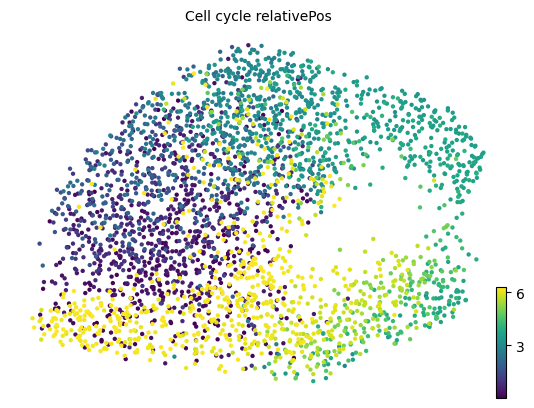

In [4]:
scv.tl.recover_dynamics(adata)      # fits gene-wise kinetics; can take a bit
scv.tl.velocity(adata)#, mode="dynamical")
scv.tl.velocity_graph(adata)
sc.tl.umap(adata)
# scv.pl.velocity_embedding_stream(adata, basis="umap")
scv.tl.velocity_pseudotime(adata)
# scv.pl.scatter(adata, color="velocity_pseudotime", cmap="viridis")
adata.obs["Cell_cycle_relativePos"] = (
    adata.obs["Cell_cycle_relativePos"]
    .astype(float)
)


scv.pl.scatter(adata, color="Cell_cycle_relativePos")

# Prepare for running CYCLO

In [5]:
pca_result =  adata.obsm['X_pca'][:, 0:2]#np.vstack([res['tricycle_dim1'],res['tricycle_dim2']]).T
print( pca_result.shape )

ys_true = (pca_result[:, :2] - pca_result[:, :2].min(0)) / np.ptp(pca_result[:, :2],0) * [8, 8] - [4, 4]
import pickle
with open('Data/scEU.p', "wb") as f:
    pickle.dump([[0],ys_true], f)
ys2,ts2,vs2 = traj_ours(1000,'Data/scEU.p',seed=0)

X = adata.X.T
print(X.shape)

T = build_laplacian(ys_true, vs2,X_full=None, k=400, threshold=0., stimulation=False)
V = find_Lie_derivative(X,T, stimulation=False)
# V = V.T
# V = X @ T.T - X @ T
# V = np.array(V)
V = V / (1e-15 + V.todense().std(axis=1).reshape(-1,1) )

/Users/wenjunzhao/Dropbox/CycleGRN/Github/CycleGRN/Utils/NN_Ours.py:392: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  XX = torch.tensor(np.meshgrid(Xf[1:-1],Yi_int[1:-1],indexing='ij'), dtype = torch.float)


(3058, 2)
Plotting Dynamics
Plotting Inferred Parameter
(2000, 3058)


/Users/wenjunzhao/Dropbox/CycleGRN/Github/CycleGRN/Utils/NN_Ours.py:362: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4424.)
  return self.net(y.T)


# First, display RNA velocity

  0%|          | 0/3058 [00:00<?, ?cell/s]

  0%|          | 0/3058 [00:00<?, ?cell/s]

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/Library/F

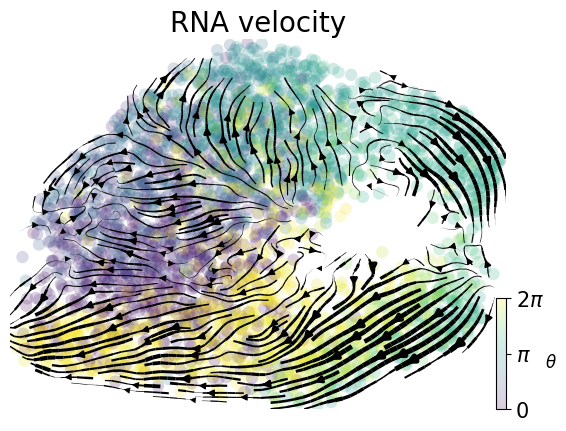

In [6]:
vk = cr.kernels.VelocityKernel(adata)
vk.compute_transition_matrix()
ck = cr.kernels.ConnectivityKernel(adata)
ck.compute_transition_matrix()

import matplotlib.pyplot as plt
import numpy as np

# 1. Run the plot command, but DO NOT save yet. 
ax = vk.plot_projection(
    recompute=True, 
    color='Cell_cycle_relativePos',
    linewidth=2, 
    title='RNA velocity', 
    fontsize=20, 
    alpha=0.2,
    show=False,   # Important: Keep plot active
    save=None     # Important: Don't save yet
)

# 2. Get the current figure
fig = plt.gcf()

# 3. Access the colorbar
cbar_ax = fig.axes[-1] 

cbar_ax.set_ylabel(r'$\theta$', fontsize=12, rotation=0, labelpad=5)
cbar_ax.set_yticks([0, np.pi, 2*np.pi])
cbar_ax.set_yticklabels(['0', '$\pi$', '$2\pi$'])

# 4. Save the figure manually now that you are done
# plt.savefig('../Figures/SCVelo/Validation_scvelo.png', dpi=300, bbox_inches='tight')
plt.show()

# Then display CYCLO velocity

  0%|          | 0/3058 [00:00<?, ?cell/s]

  0%|          | 0/3058 [00:00<?, ?cell/s]

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/Library/F

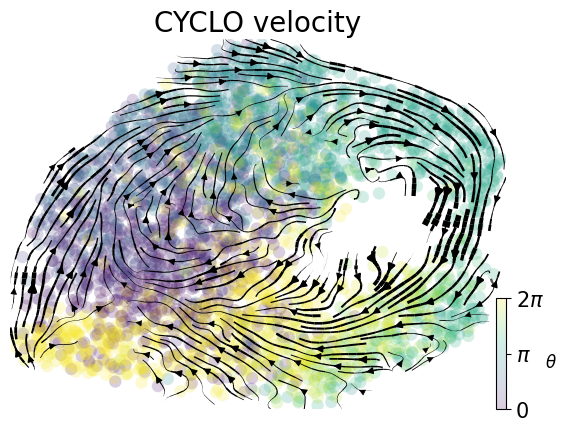

In [7]:
adata.layers['my_velocity'] = V.T.tocsr() #np.asarray(V).T

vk_my = cr.kernels.VelocityKernel(adata, vkey="my_velocity")
vk_my.compute_transition_matrix()

import matplotlib.pyplot as plt
import numpy as np

# 1. Run the plot command, but DO NOT save yet. 
# Set show=False so we can modify it before it renders/closes.
ax = vk_my.plot_projection(
    recompute=True, 
    color='Cell_cycle_relativePos',
    linewidth=3, 
    title='CYCLO velocity', 
    fontsize=20, 
    alpha=0.2,
    show=False,   # Important: Keep plot active
    save=None     # Important: Don't save yet
)

# 2. Get the current figure
fig = plt.gcf()

# 3. Access the colorbar
# In these plots, the colorbar is usually the last axis added to the figure.
cbar_ax = fig.axes[-1] 

# --- OPTION A: Change the Title ---
cbar_ax.set_ylabel(r'$\theta$', fontsize=12, rotation=0, labelpad=5)

# --- OPTION B: Change Ticks (e.g., to 0, pi, 2pi) ---
# Assuming your data ranges roughly from 0 to 6.28
cbar_ax.set_yticks([0, np.pi, 2*np.pi])
cbar_ax.set_yticklabels(['0', '$\pi$', '$2\pi$'])

# 4. Save the figure manually now that you are done
# plt.savefig('../Figures/SCVelo/Validation.png', dpi=300, bbox_inches='tight')
plt.show()

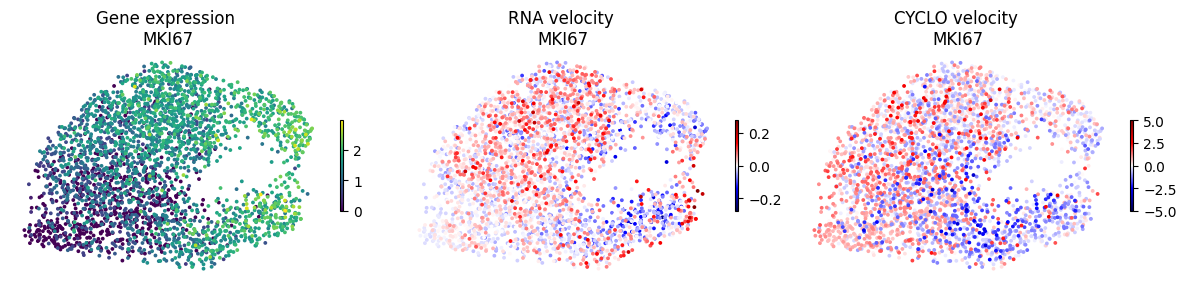

In [8]:
import matplotlib.pyplot as plt
import numpy as np

gene_id = 1161
# gene_id = 807
fig = plt.figure(figsize=(12, 3))  # width, height in inches

# --- 1. Gene Expression ---
ax1 = plt.subplot(1, 3, 1)
c = np.array(adata[:, adata.var_names[gene_id]].X.todense()).reshape(-1)
order = np.argsort(abs(c))
sc1 = plt.scatter(
    adata.obsm['X_umap'][order, 0],
    adata.obsm['X_umap'][order, 1],
    c=c[order],
    s=3
)
cbar = plt.colorbar(
    sc1, 
    ax=ax1,            # <--- Attach to the 3rd plot
    fraction=0.046, 
    pad=0.04, 
    shrink=0.4,        # <--- 40% height (Tiny)
    aspect=30          # <--- Thinner bar
)

plt.title("Gene expression \n" + adata.var_names[gene_id])
plt.axis('off')

# --- 2. scVelo Velocity ---
ax2 = plt.subplot(1, 3, 2)
order = np.argsort(adata.layers['velocity'][:, gene_id])
sc3 = plt.scatter(
    adata.obsm['X_umap'][order, 0],
    adata.obsm['X_umap'][order, 1],
    c=adata.layers['velocity'][order, gene_id],
    cmap='seismic',
    s=3
)
plt.clim(
    -5 * np.std(adata.layers['velocity'][order, gene_id]),
     5 * np.std(adata.layers['velocity'][order, gene_id])
)
plt.title("RNA velocity \n" + adata.var_names[gene_id])
plt.axis('off')

# --- THE TINY COLORBAR ---
# We attach it explicitly to 'ax3' (the current subplot)
cbar = plt.colorbar(
    sc3, 
    ax=ax2,            # <--- Attach to the 3rd plot
    fraction=0.046, 
    pad=0.04, 
    shrink=0.4,        # <--- 40% height (Tiny)
    aspect=30          # <--- Thinner bar
)

# --- 3. Our Velocity ---
ax3 = plt.subplot(1, 3, 3)
V = np.array(V.todense())
order = np.argsort(abs(V[gene_id, :]))
sc4 = plt.scatter(
    adata.obsm['X_umap'][order, 0],
    adata.obsm['X_umap'][order, 1],
    c=V[gene_id, order],
    cmap='seismic',
    s=3
)
plt.clim(
    -5 * np.std(V[gene_id, order]),
     5 * np.std(V[gene_id, order])
)
plt.title("CYCLO velocity \n" + adata.var_names[gene_id])
plt.axis('off')

# --- THE TINY COLORBAR ---
# We attach it explicitly to 'ax3' (the current subplot)
cbar = plt.colorbar(
    sc4, 
    ax=ax3,            # <--- Attach to the 3rd plot
    fraction=0.046, 
    pad=0.04, 
    shrink=0.4,        # <--- 40% height (Tiny)
    aspect=30          # <--- Thinner bar
)

plt.tight_layout()
# plt.savefig("../Figures/SCVelo/Mki67_distribution.pdf", dpi=300, bbox_inches='tight')
plt.show()


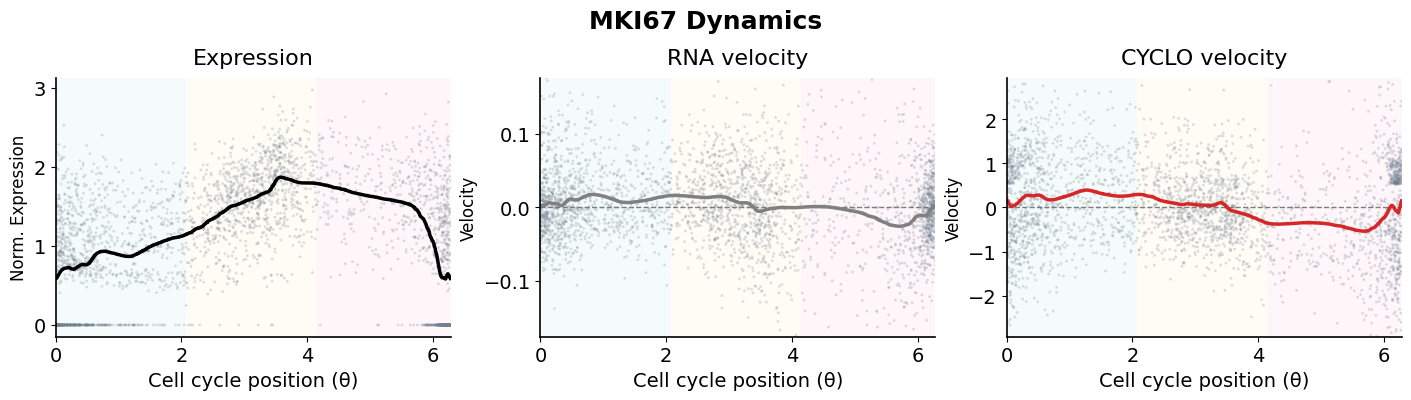

In [9]:
def symmetric_ylim(y, q=0.99, pad=1.1):
    m = np.quantile(np.abs(y), q)
    return (-pad * m, pad * m)

import numpy as np
from scipy.ndimage import gaussian_filter1d

def circular_smooth(x, y, sigma=40):
    x = np.asarray(x); y = np.asarray(y)
    order = np.argsort(x)
    x0 = x[order]; y0 = y[order]

    # duplicate data: [x, x+1, x+2]
    x3 = np.concatenate([x0, x0 + 1, x0 + 2])
    y3 = np.concatenate([y0, y0, y0])

    y3s = gaussian_filter1d(y3, sigma=sigma, mode="nearest")

    # take the middle copy (x in [1,2]) and shift back to [0,1]
    mid = (x3 >= 1) & (x3 <= 2)
    x_mid = x3[mid] - 1
    y_mid = y3s[mid]

    # restore increasing x in [0,1]
    ord2 = np.argsort(x_mid)
    return x_mid[ord2], y_mid[ord2]


import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Setup for publication aesthetics
plt.rcParams['font.family'] = 'sans-serif' # Arial/Helvetica are standard
plt.rcParams['font.size'] = 14
plt.rcParams['axes.linewidth'] = 1.2

# Define data inputs (Mapping title to data source)
# calculating these upfront makes the plotting loop cleaner
x = adata.obs["Cell_cycle_relativePos"].to_numpy()/2/np.pi
order = np.argsort(x)
y_expr = np.array(adata[:, adata.var_names[gene_id]].X.todense()).reshape(-1)
y_scvelo = np.asarray(adata.layers['velocity'][:, gene_id]).ravel()
y_our = V[gene_id, :]
# y_ot = V_OT[:,gene_id]

data_map = [
    {"data": y_expr, "title": "Expression", "ylabel": "Norm. Expression", "is_vel": False, "color": "black"},
    {"data": y_scvelo, "title": "RNA velocity", "ylabel": "Velocity", "is_vel": True, "color": "grey"},
    {"data": y_our, "title": "CYCLO velocity", "ylabel": "Velocity", "is_vel": True, "color": "#d62728"}, # Highlight your method with color
   # {"data": y_ot, "title": "OT velocity", "ylabel": "Velocity", "is_vel": True, "color": 'tab:blue'} # Highlight your method with color

]

# Create Figure
fig, axes = plt.subplots(1, len(data_map), figsize=(14, 3.5), constrained_layout=True)

# Main Title (The Gene Name)
gene_name = adata.var['gene_symbol'][gene_id]
fig.suptitle(f"{gene_name} Dynamics", fontsize=18, weight='bold', y=1.1)

for ax, d in zip(axes, data_map):
    y = d["data"] 
    
    # 1. Plot Scatter (Rasterized for PDF export efficiency)
    ax.scatter(x* 2 * np.pi, y, s=4, alpha=0.25, color="slategray", rasterized=True, edgecolor='none')
    
    # 2. Plot Trend Line
    xs, ys = circular_smooth(x[order], y[order], sigma=50)
    ax.plot(xs* 2 * np.pi, ys, lw=2.5, color=d["color"], label='Trend')
    
    # 3. Add Zero Line for velocities
    if d["is_vel"]:
        ax.axhline(0, lw=1, linestyle='--', color="black", alpha=0.5, zorder=0)
        ax.set_ylim(*symmetric_ylim(y))
        
    # 4. Aesthetics
    ax.set_title(d["title"], fontsize=16, pad=10)
    ax.set_xlabel("Cell cycle position (θ)")
    
    # Only show Y label if helpful, or simplistic styling
    ax.set_ylabel(d["ylabel"], fontsize=12)
    
    # Remove top and right spines (classic scientific style)
    sns.despine(ax=ax)

phases = [
    (0.0, 0.33*2*np.pi, "G1", "#e0f2f1"),   # Light Teal
    (0.33*2*np.pi, 0.66*2*np.pi, "S", "#fff3e0"),   # Light Orange
    (0.66*2*np.pi, 2*np.pi, "G2/M", "#fce4ec")  # Light Pink
]

for ax in axes:
    ax.set_xlim([0,2*np.pi])
    for start, end, label, color in phases:
        # Add colored background
        ax.axvspan(start, end, color=color, alpha=0.3, zorder=-10, lw=0)
        
        # Optional: Add text labels at the top of the plot
        # only do this on the middle plot to avoid clutter
        if False:#x == axes[0]: 
            mid_point = (start + end) / 2
            ax.text(mid_point, ax.get_ylim()[1] - 0.2, label, 
                    ha='center', va='bottom', fontsize=10, color='black')

# Save as high-res
# plt.savefig("../Figures/SCVelo/Mki67_dynamics.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [10]:
import numpy as np

V_my = np.asarray(V)                      # (n_genes, n_cells) expected
V_sc = adata.layers["velocity"]           # (n_cells, n_genes)

# ensure dense 2D ndarray for V_sc (only if needed)
V_sc = np.asarray(V_sc)                   # may be big; if too big, do gene-by-gene

q = 0.9
min_support = 30  # require at least this many cells passing the mask per gene

agree = np.full(V_my.shape[0], np.nan)
support = np.zeros(V_my.shape[0], dtype=int)

for g in range(V_my.shape[0]):
    v_my = V_my[g, :]            # (n_cells,)
    v_sc = V_sc[:, g]            # (n_cells,)

    thr_sc = np.quantile(np.abs(v_sc), q)
    thr_my = np.quantile(np.abs(v_my), q)

    mask = (np.abs(v_sc) > thr_sc) & (np.abs(v_my) > thr_my)
    m = int(mask.sum())
    support[g] = m
    if m < min_support:
        continue

    agree[g] = np.mean((v_my[mask] * v_sc[mask]) >= 0)

rng = np.random.default_rng(0)
agree_null = np.full(V_my.shape[0], np.nan)

for g in range(V_my.shape[0]):
    v_my = V_my[g, :]
    v_sc = V_sc[:, g]
    thr_sc = np.quantile(np.abs(v_sc), q)
    thr_my = np.quantile(np.abs(v_my), q)
    mask = (np.abs(v_sc) > thr_sc) & (np.abs(v_my) > thr_my)
    m = int(mask.sum())
    if m < min_support:
        continue
    v_sc_shuf = v_sc[rng.permutation(v_sc.shape[0])]
    agree_null[g] = np.mean((v_my[mask] * v_sc_shuf[mask]) >= 0)

q = 0.5
min_support = 30  # require at least this many cells passing the mask per gene

# V_ot = np.asarray(V_OT.T)
# agree_ot = np.full(V_ot.shape[0], np.nan)
# support_ot = np.zeros(V_ot.shape[0], dtype=int)

# for g in range(V_my.shape[0]):
#     v_ot = V_ot[g, :]            # (n_cells,)
#     v_sc = V_sc[:, g]            # (n_cells,)

#     thr_sc = np.quantile(np.abs(v_sc), q)
#     thr_ot = np.quantile(np.abs(v_ot), q)

#     mask = (np.abs(v_sc) > thr_sc) & (np.abs(v_ot) > thr_ot)
#     m = int(mask.sum())
#     support_ot[g] = m
#     if m < min_support:
#         continue

#     agree_ot[g] = np.mean((v_ot[mask] * v_sc[mask]) >= 0)

Text(0.5, 1.0, 'Sign agreement among \n high-magnitude velocity entries')

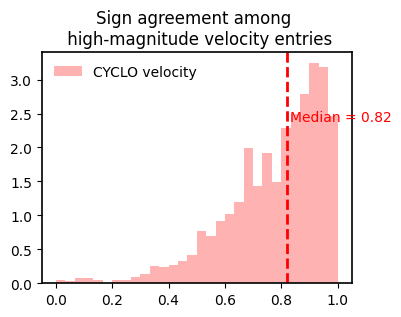

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# remove NaNs
agree_clean = agree[~np.isnan(agree)]
agree_null_clean = agree_null[~np.isnan(agree_null)]

bins = np.linspace(0, 1, 31)
plt.rcParams['font.size'] = 10
plt.figure(figsize=(4, 3))

med_obs = np.nanmedian(agree_clean)
med_null = np.nanmedian(agree_null_clean)
# med_ot = np.nanmedian(agree_ot)

plt.hist(
    agree_clean,
    bins=bins,
    density=True,
    alpha=0.3,
    color='red',
    label=f"CYCLO velocity",
)


# vertical median lines
# plt.axvline(med_null, color="slategray", linestyle="--", lw=2)
plt.axvline(med_obs, color="red", linestyle="--", lw=2)
# plt.axvline(med_ot, color="tab:blue", linestyle="--", lw=2)
# annotate medians
ymax = plt.ylim()[1]

# plt.text(
#     med_null + 0.01,
#     0.9 * ymax,
#     f"Median = {med_null:.2f}",
#     color="slategray",
#     ha="left",
#     va="top",
# )

plt.text(
    med_obs + 0.01,
    0.75 * ymax,
    f"Median = {med_obs:.2f}",
    color="red",
    ha="left",
    va="top",
)

# plt.text(
#     med_ot - 0.2,
#     0.5 * ymax,
#     f"Median = {med_ot:.2f}",
#     color="tab:blue",
#     ha="left",
#     va="top",
# )

plt.legend(frameon=False)
plt.title("Sign agreement among \n high-magnitude velocity entries")

# Nominate genes with high coherence score

Ranking 1972 genes (excluded 28 MT/RP genes)...
        gene  coherence_score
549      FN1         0.526710
646     TMPO         0.463481
481     NOP2         0.457524
1004  DIAPH3         0.432812
1879   NALF1         0.421727
154   MAP4K4         0.409462
1089   NCEH1         0.407426
1380   TTC14         0.383157
1640   MLXIP         0.381083
839    SORT1         0.380394
Ranking 1972 genes (excluded 28 MT/RP genes)...
          gene  coherence_score
1829      H4C3         0.201112
811       PCNA         0.200708
183        UNG         0.177040
1630     UBE2C         0.174296
276       CDC6         0.160669
177       ACTB         0.160060
603      CENPF         0.153291
1548      CDK1         0.148441
801      TOP2A         0.146977
1933  MTATP6P1         0.139641
Ranking 1972 genes (excluded 28 MT/RP genes)...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/anndata/_core/aligned_mapping.py:218: ImplicitModificationWarning: Layer 'counts' should not be a np.matrix, use np.ndarray instead.
  value = self._validate_value(value, key)


         gene  coherence_score
1018     PIF1         0.629888
319    SACK1D         0.470212
655    PDZRN3         0.413223
1716    PAPPA         0.403102
432    FBXL20         0.402226
1635    CCNE2         0.396085
1269  GLYATL2         0.395471
1326     CCNF         0.391811
544     CENPA         0.389379
1564     XKR6         0.389314


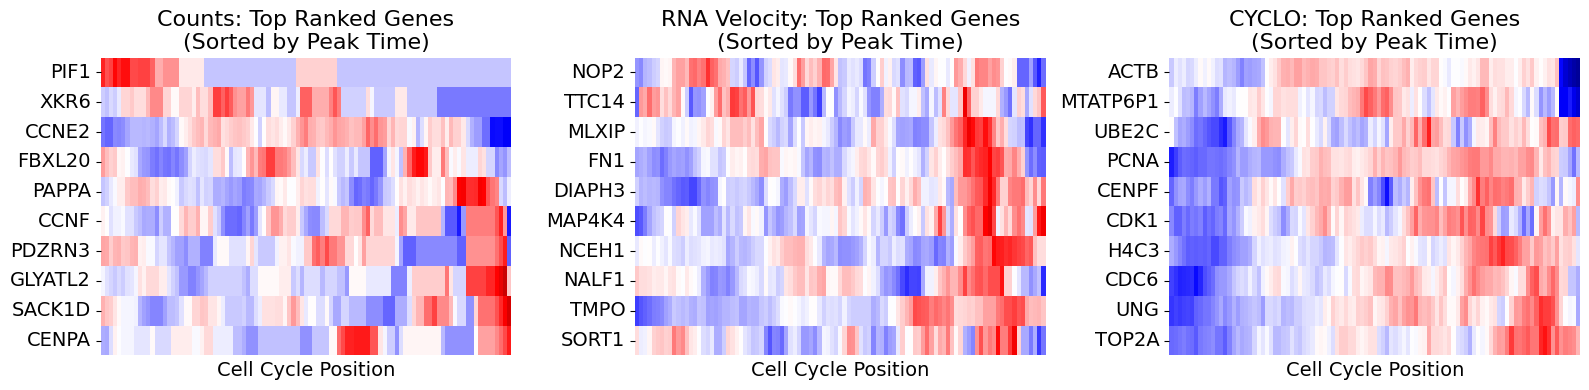

In [12]:
import pandas as pd
import numpy as np

def rank_genes_by_coherence_clean(adata, velocity_layer='velocity', theta_key='Cell_cycle_relativePos'):
    scores = []
    scores_var = []
    # 1. Identify genes to SKIP
    # Adjust prefixes if needed (e.g., 'mt-' for mouse, 'MT-' for human)
    ignore_prefixes = ('MT-', 'RPS', 'RPL', 'MRPS', 'MRPL', 'None') 
    
    # Filter var_names directly
    candidates = [g for g in adata.var_names if not g.startswith(ignore_prefixes)]
    
    print(f"Ranking {len(candidates)} genes (excluded {adata.n_vars - len(candidates)} MT/RP genes)...")

    for gene in candidates:
        # Get Velocity
        v = adata[:, gene].layers[velocity_layer]
        if hasattr(v, "todense"): v = v.todense().flatten()
        
        # Get Phase (0 to 1)
        theta = adata.obs[theta_key].values
        
        # Skip genes with zero velocity (no dynamics)
        if np.sum(np.abs(v)) == 0:
            continue
            
        v = np.asarray(v).ravel()
        theta = np.asarray(theta).ravel()
        complex_phase = np.exp(1j * theta)
        weighted_sum = np.sum(v * complex_phase)
        
        # Normalize by total velocity magnitude so high expression doesn't bias score
        score = np.abs(weighted_sum) / np.sum(np.abs(v))
            
        scores.append({'gene': gene, 'coherence_score': score})


        c1 = np.sum(v * np.cos(theta))
        c2 = np.sum(v * np.sin(theta))
        scores_var.append({'gene':gene, 'var_theta': np.sqrt(c1**2 + c2**2) / np.sum(np.abs(v))})

        
        
    return pd.DataFrame(scores).sort_values('coherence_score', ascending=False), pd.DataFrame(scores_var).sort_values('var_theta', ascending=False)

# Run the cleaned ranking
gene_ranks, _ = rank_genes_by_coherence_clean(adata)
print(gene_ranks.head(10))

gene_ranks_my,_ = rank_genes_by_coherence_clean(adata, velocity_layer='my_velocity')
print(gene_ranks_my.head(10))

adata.layers['counts'] = adata.X.copy().todense()
gene_ranks_gene, _ = rank_genes_by_coherence_clean(adata, velocity_layer='counts')
print(gene_ranks_gene.head(10))


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd # Added for potential smoothing if needed

# 1. Define the two lists
scvelo_genes = gene_ranks['gene'].head(10).tolist()
our_genes = gene_ranks_my['gene'].head(10).tolist()
count_genes = gene_ranks_gene['gene'].head(10).tolist()

# Helper function that returns the matrix AND the peak location
def get_heatmap_data(genes, adata):
    n_bins = 100
    bins = np.linspace(0, 1, n_bins)
    matrix = []
    names = []
    peak_positions = []
    
    for gene in genes:
        try:
            # Get Expression Data
            data = np.array(adata[:, gene].X.todense()).flatten()
        except:
            continue
            
        theta = adata.obs['Cell_cycle_relativePos'].values
        
        # Binning & Smoothing
        digitized = np.digitize(theta, bins)
        smooth_curve = []
        for i in range(1, len(bins)):
            mask = digitized == i
            if np.any(mask):
                smooth_curve.append(np.mean(data[mask]))
            else:
                smooth_curve.append(0)
        
        # Smooth the line to find a clear peak
        smooth_series = pd.Series(smooth_curve).rolling(window=10, center=True, min_periods=1).mean().values
        
        # Normalize (Z-score)
        if np.std(smooth_series) == 0:
            z_score = smooth_series
        else:
            z_score = (smooth_series - np.mean(smooth_series)) / np.std(smooth_series)
            
        matrix.append(z_score)
        names.append(gene)
        # Find index of max value (Peak Phase)
        peak_positions.append(np.argmax(smooth_series))
    
    return np.array(matrix), names, np.array(peak_positions)

# 2. Get Data
mat_scvelo, names_scvelo, peaks_scvelo = get_heatmap_data(scvelo_genes, adata)
mat_ours, names_ours, peaks_ours = get_heatmap_data(our_genes, adata)
mat_count, names_count, peaks_count = get_heatmap_data(count_genes, adata)

# 3. SORT BY PEAK (The Critical Step)
# We zip them together, sort by peak index, and unzip
order_scvelo = np.argsort(peaks_scvelo)
mat_scvelo_sorted = mat_scvelo[order_scvelo]
names_scvelo_sorted = [names_scvelo[i] for i in order_scvelo]

order_ours = np.argsort(peaks_ours)
mat_ours_sorted = mat_ours[order_ours]
names_ours_sorted = [names_ours[i] for i in order_ours]

order_count = np.argsort(peaks_count)
mat_count_sorted = mat_count[order_count]
names_count_sorted = [names_count[i] for i in order_count]

# 4. Plot
# Increase width slightly (16) to accommodate the side bar
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False) 
limit = 5.5
font_size = 14

sns.heatmap(
    mat_count_sorted, 
    cmap='seismic', 
    ax=axes[0], 
    cbar=False,            # Turn off internal colorbar
    xticklabels=False, 
    yticklabels=names_count_sorted,
    center=0, vmin=-limit, vmax=limit
)
axes[0].set_title("Counts: Top Ranked Genes\n(Sorted by Peak Time)", fontsize=16)
axes[0].set_xlabel("Cell Cycle Position", fontsize=14)
axes[0].tick_params(axis='y', labelsize=font_size)


# --- PLOT 1: scVelo (No Colorbar) ---
sns.heatmap(
    mat_scvelo_sorted, 
    cmap='seismic', 
    ax=axes[1], 
    cbar=False,            # Turn off internal colorbar
    xticklabels=False, 
    yticklabels=names_scvelo_sorted,
    center=0, vmin=-limit, vmax=limit
)
axes[1].set_title("RNA Velocity: Top Ranked Genes\n(Sorted by Peak Time)", fontsize=16)
axes[1].set_xlabel("Cell Cycle Position", fontsize=14)
axes[1].tick_params(axis='y', labelsize=font_size)

# --- PLOT 2: Our Method (Link Colorbar to external axis) ---

sns.heatmap(
    mat_ours_sorted, 
    cmap='seismic', 
    ax=axes[2], 
    cbar=False,             # Turn on...
    # cbar_ax=cbar_ax,       # ...but draw it in this specific box
    xticklabels=False, 
    yticklabels=names_ours_sorted,
    center=0, vmin=-limit, vmax=limit, 
    # cbar_kws={'label': 'Z-scored Expression'}
)
axes[2].set_title("CYCLO: Top Ranked Genes\n(Sorted by Peak Time)", fontsize=16)
axes[2].set_xlabel("Cell Cycle Position", fontsize=14)
axes[2].tick_params(axis='y', labelsize=font_size)

# Style the separate colorbar
# cbar_ax.tick_params(labelsize=12)
# cbar_ax.yaxis.label.set_size(14)

# Adjust layout to leave room on the right for the bar
# plt.subplots_adjust(right=0.8) 
plt.tight_layout()
# plt.savefig('../Figures/SCVelo/drivers.png',bbox_inches='tight')
plt.show()